<a href="https://colab.research.google.com/github/glisserok/grigoriyvolkov/blob/main/Laba_2_KSVD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Перші 5 рядків:
   rank                    Youtuber  subscribers   video views  \
0     1                    T-Series    245000000  2.280000e+11   
1     2              YouTube Movies    170000000  0.000000e+00   
2     3                     MrBeast    166000000  2.836884e+10   
3     4  Cocomelon - Nursery Rhymes    162000000  1.640000e+11   
4     5                   SET India    159000000  1.480000e+11   

           category                       Title  uploads        Country  \
0             Music                    T-Series    20082          India   
1  Film & Animation               youtubemovies        1  United States   
2     Entertainment                     MrBeast      741  United States   
3         Education  Cocomelon - Nursery Rhymes      966  United States   
4             Shows                   SET India   116536          India   

  Abbreviation   channel_type  ...  subscribers_for_last_30_days  \
0           IN          Music  ...                     2000000.0   


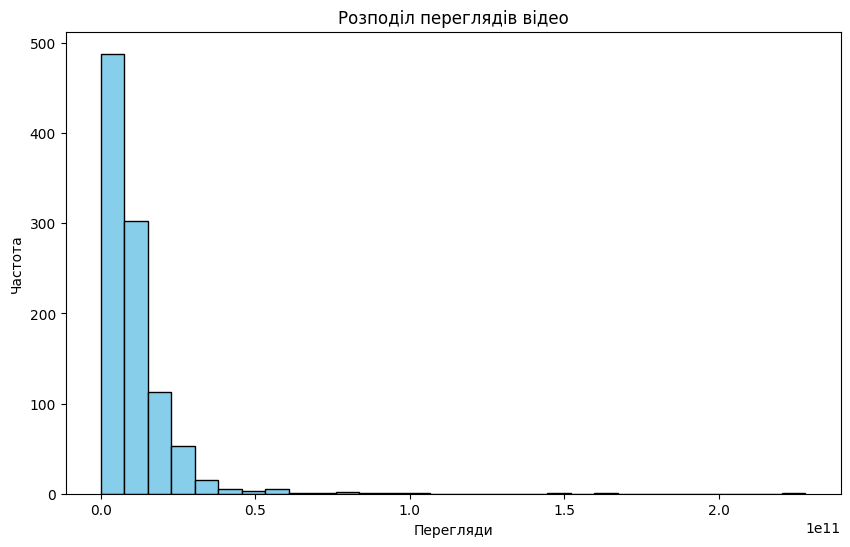


Максимальна кількість переглядів: 228000000000.0
Мінімальна кількість переглядів: 0.0
Середня кількість переглядів: 11039537052.03819

Країна з найбільшою кількістю завантажень: India

Відео з найбільшою кількістю завантажень: ABP NEWS
Відео з найменшою кількістю завантажень: Music


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('Global YouTube Statistics.csv', encoding='latin-1')

print("Перші 5 рядків:")
print(df.head())

print(f"\nРозмір датасету: {df.shape}")

print("\nКількість пропусків до обробки:")
print(df.isna().sum())

numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean()).astype(float)

print("\nКількість пропусків після обробки (числові стовпці):")
print(df[numeric_cols].isna().sum())

unique_countries = df['Country'].nunique()
print(f"\nУнікальних країн: {unique_countries}")

plt.figure(figsize=(10, 6))
df['video views'].plot(kind='hist', bins=30, color='skyblue', edgecolor='black')
plt.title('Розподіл переглядів відео')
plt.xlabel('Перегляди')
plt.ylabel('Частота')
plt.show()

print(f"\nМаксимальна кількість переглядів: {df['video views'].max()}")
print(f"Мінімальна кількість переглядів: {df['video views'].min()}")
print(f"Середня кількість переглядів: {df['video views'].mean()}")

country_most_uploads = df.groupby('Country')['uploads'].sum().idxmax()
print(f"\nКраїна з найбільшою кількістю завантажень: {country_most_uploads}")

video_max_up = df.loc[df['uploads'].idxmax(), 'Title']
video_min_up = df.loc[df['uploads'].idxmin(), 'Title']
print(f"\nВідео з найбільшою кількістю завантажень: {video_max_up}")
print(f"Відео з найменшою кількістю завантажень: {video_min_up}")

In [ ]:
import pandas as pd

df_books = pd.read_csv('bestsellers with categories.csv')

print("Перші 10 рядків:")
print(df_books.head(10))

print(f"\nРозмір датасету: {df_books.shape}")
print(f"Датасет зберігає дані про {df_books.shape[0]} книг")

df_books.columns = ['name', 'author', 'user_rating', 'reviews', 'price', 'year', 'genre']

missing_counts = df_books.isna().sum()
print("\nКількість пропусків:")
print(missing_counts)
print(f"Чи є в якихось змінних пропуски? {'Так' if missing_counts.any() else 'Ні'}")

unique_genres = df_books['genre'].unique()
print(f"\nУнікальні жанри: {unique_genres}")

print(f"\nМаксимальна ціна: {df_books['price'].max()}")
print(f"Мінімальна ціна: {df_books['price'].min()}")
print(f"Середня ціна: {df_books['price'].mean()}")
print(f"Медіанна ціна: {df_books['price'].median()}")

max_rating = df_books['user_rating'].max()
print(f"\nНайвищий рейтинг: {max_rating}")

count_max_rating = df_books[df_books['user_rating'] == max_rating].shape[0]
print(f"Кількість книг з таким рейтингом: {count_max_rating}")

book_most_reviews = df_books.loc[df_books['reviews'].idxmax(), 'name']
print(f"Книга з найбільшою кількістю відгуків: {book_most_reviews}")

expensive_2010 = df_books[df_books['year'] == 2010].sort_values('price', ascending=False).iloc[0]['name']
print(f"Найдорожча книга 2010 року: {expensive_2010}")

fiction_2012 = df_books[(df_books['genre'] == 'Fiction') & (df_books['year'] == 2012)].shape[0]
print(f"Кількість книг Fiction у 2012 році: {fiction_2012}")

rating_49_count = df_books[(df_books['user_rating'] == 4.9) & (df_books['year'].isin([2010, 2011]))].shape[0]
print(f"Кількість книг з рейтингом 4.9 (2010-2011): {rating_49_count}")

genre_prices = df_books.groupby('genre')['price'].agg(['max', 'min'])
print("\nМаксимальна та мінімальна ціни за жанрами:")
print(genre_prices)

Перші 10 рядків:
                                                Name  \
0                      10-Day Green Smoothie Cleanse   
1                                  11/22/63: A Novel   
2            12 Rules for Life: An Antidote to Chaos   
3                             1984 (Signet Classics)   
4  5,000 Awesome Facts (About Everything!) (Natio...   
5      A Dance with Dragons (A Song of Ice and Fire)   
6  A Game of Thrones / A Clash of Kings / A Storm...   
7                     A Gentleman in Moscow: A Novel   
8      A Higher Loyalty: Truth, Lies, and Leadership   
9                          A Man Called Ove: A Novel   

                     Author  User Rating  Reviews  Price  Year        Genre  
0                  JJ Smith          4.7    17350      8  2016  Non Fiction  
1              Stephen King          4.6     2052     22  2011      Fiction  
2        Jordan B. Peterson          4.7    18979     15  2018  Non Fiction  
3             George Orwell          4.7    21424     